**Task 1.1**

In [ ]:
#Importing the libraries
import pandas as pd
import numpy as np



In [ ]:
#reading and storring the data
df = pd.read_csv("Data-Titanic.csv")

In [ ]:
#printing the first few rows
df.head()

In [ ]:
#Printing the shape of the dataset
print(df.shape)

In the past cells I imported the necessary libraries for the data, then I loaded the data, printed the first 5 rows, then I checked how many columns and rows it has

In [ ]:
#Checking for missing vals

#Replacing the undetected nulls with the ones that pandas knows
notdetect = ["N\\A","NA","not reported", "unknown", "?"] # the unknown nulls to pandas
df = df.replace(notdetect, np.nan)

#Checking the number of nulls in each col
print("----------Num Of Nulls-------")
print(df.isna().sum())

#Dropping what needs to be dropped
df = df.drop(["Cabin"], axis=1) #The most of this col is null, so its better to drop it, becuase its hard to fill it.
df = df.dropna() # I removed the rest of the rows that had any nulls, becuase its hard to fill and anticipate someones age and where they embarked from.

In [ ]:
#Checking class balance
df.info() # We can see that all the cols have the same num of rows, 712 rows.

In the past 2 cells I first made sure that the machine can detect all the nulls that are in the data, then I checked how many nulls were in the data and should i remove or fill them.
After removing them i checked the datas shape, to check that all the columns have the same amount of rows

**Task 1.2**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Survived", "Name", "Sex", "Ticket", "Embarked"])
y = df["Survived"] # I didn't understand how to do this code, so i copiedd the instrucion and gave it to gemini to help me understand, then i wrote the code.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
) #This code and the import, i took it from the given file.

In this cell I import a function "train_test_split" from the sklearn.model_selection library, why?
to split my data into train data to train my model, and test data to test my model and make sure that its good

**Task 1.3**

In [ ]:
#Imports for training the models and also to see there metrics and stats.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt


In [ ]:
#Training the models and reporting important metrics
random_state = 42
models = {
    "LogisticRegression": LogisticRegression(max_iter=200),
    "KNN":  KNeighborsClassifier(n_neighbors=5,),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=random_state),
}

results = [] # For every model, train it then measure its metrics then save them in the results list.
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    results.append((name, acc, prec, rec, f1))

results_df = pd.DataFrame(results, columns=["model", "accuracy", "precision", "recall", "f1"]) #Turn the results list into a df
print(results_df.sort_values(by="f1", ascending=False)) # Sorting the df to see the best model of them all

#I took this code from numerous colab notebooks, that are provided in the slides, but i also made some changes.
# https://colab.research.google.com/drive/1MkpN2aAzzx1BG4LpKOtwa8G6nuB9svdb?usp=drive_link#scrollTo=RE_k_sdLVjKv
# https://colab.research.google.com/drive/1iGWgVJiLxnEJc764piC_SVsfl8Abi3EP?usp=sharing#scrollTo=E8dFKjt_3uRA



In [ ]:
#Ploting a confusion matrix for each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm)
    disp.plot(cmap="Blues")
    plt.title(name)
    plt.show()


In the past 2 cells, I first imported some libraries to help in completing this task, then I trained 3 models, LogisticRegression, KNN and RandomForest.
Then I made each model a made a simple report on each model using its metrics then I finally made a confusion matrix for each

In [ ]:
#Putting the results in one summary table
result_list=[]
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    #Entering vals into the made list
    result_list.append({
        "Name": name,
        "Accuracy" : acc,
        "Precision" : prec,
        "Recall" : rec,
        "F1 Score" : f1
    })
#Turning the list into a pd dataframe
summary_df = pd.DataFrame(result_list)
#Sorting the vals by f1 score to find the best model,
summary_df = summary_df.sort_values(by= "F1 Score", ascending=False).reset_index(drop=True)
display(summary_df)
#When looking at the table, we find that the RandomForest model is the best based on the f1 score!


#I used gemini to help in understanding the instruction, and implementing the code, but I was the one who wrote the code.


Here i did the process again but made it more tidy and neat, then I put the results in a dataframe and sorted it then displayed it


**Task 2.1**

In [ ]:
# Importing the libraries to make the neural network
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Sequential
from tensorflow.keras.utils import to_categorical


In [ ]:
input_dim = X_train.shape[1] #Seeing how many cols in the df
hidden_1 = 8 #How many neurons the first layer has
hidden_2 = 4 # How many neurons the second layer has
hidden_activation = "relu"
epochs = 10 #How many times the model trains on the data
dropout_rate = 0.3 #How many neurons we drop


In these 2 cells i import the libraries needed for neural networks, and then i made some variables for how much columns there are, how much neurons in the layers, how many times the model goes through the data, how many neurons we drop and some more.

In [ ]:
#Sigmoid plain without dropout
model_sigmoid_plain = Sequential([
    Dense(hidden_1, activation = hidden_activation, input_shape =(input_dim,)),
    Dense(hidden_2, activation = hidden_activation),
    Dense(1, activation = "sigmoid")
])

model_sigmoid_plain.compile(
              optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"]) #Configuring its settings

model_sigmoid_plain_fit = model_sigmoid_plain.fit(
    X_train, y_train,
    epochs=epochs) #Training the neural network

#Sigmoid with dropout
model_sigmoid_wDO = Sequential([
    Dense(hidden_1, activation = hidden_activation, input_shape =(input_dim,)),
    Dropout(dropout_rate),
    Dense(hidden_2, activation = hidden_activation),
    Dropout(dropout_rate),
    Dense(1, activation = "sigmoid")
])

model_sigmoid_wDO.compile(
              optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])#Configuring its settings

model_sigmoid_fit = model_sigmoid_plain.fit(X_train, y_train,
                                            epochs=epochs,
                                            validation_data = (X_test, y_test))#Training the neural network

model_sigmoid_wDo_fit = model_sigmoid_wDO.fit(X_train, y_train,
                                              epochs=epochs,
                                              validation_data = (X_test, y_test))
print("training accuracy:", round(float(model_sigmoid_fit.history["accuracy"][-1]), 3))
print("Final training with Dropout layers accuracy:", round(float(model_sigmoid_wDo_fit.history["accuracy"][-1]), 3))


In [ ]:
#Softmax
y_train_encoded = to_categorical(y_train, num_classes = 2)
y_test_encoded = to_categorical(y_test, num_classes = 2)

#Softmax without dropout
model_softmax_plain = Sequential([
    Dense(hidden_1, activation = hidden_activation, input_shape = (input_dim,)),
    Dense(hidden_2, activation = hidden_activation),
    Dense(2, activation="softmax")
])

model_softmax_plain.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])


#Softmax with dropout
model_softmax_wDO = Sequential([
    Dense(hidden_1, activation = hidden_activation, input_shape = (input_dim,)),
    Dropout(dropout_rate),
    Dense(hidden_2, activation = hidden_activation),
    Dropout(dropout_rate),
    Dense(2, activation="softmax")
])

model_softmax_wDO.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])




model_softmax_plain.compile(optimizer= "adam", loss ="categorical_crossentropy", metrics = ["accuracy"])
model_softmax_fit = model_softmax_plain.fit(X_train,y_train_encoded,
                                            epochs = epochs,
                                            validation_data = (X_test, y_test_encoded))
model_softmax_wDo_fit = model_softmax_wDO.fit(X_train, y_train_encoded,
                                              epochs=epochs,
                                              validation_data= (X_test, y_test_encoded))

print("training accuracy:", round(float(model_softmax_fit.history["accuracy"][-1]), 3))
print("Final training with Dropout layers accuracy:", round(float(model_softmax_wDo_fit.history["accuracy"][-1]), 3))


Here I trained the neural network using sigmoid and also softmax, and also I tried some dropout layers, then in the end i compared there accuracies to see which was best


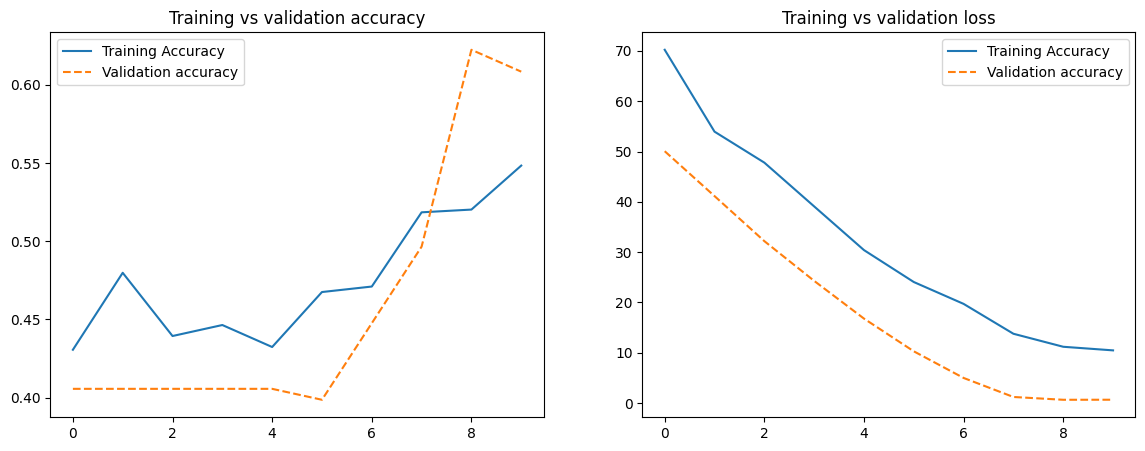

In [50]:
#plotting for softmax with dropout


fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14, 5) )



#Accuracy
ax1.plot(model_softmax_wDo_fit.history["accuracy"], label = "Training Accuracy")
ax1.plot(model_softmax_wDo_fit.history["val_accuracy"], label = "Validation accuracy", linestyle = "--")
ax1.set_title("Training vs validation accuracy")
ax1.legend()


#loss
ax2.plot(model_softmax_wDo_fit.history["loss"], label = "Training Accuracy")
ax2.plot(model_softmax_wDo_fit.history["val_loss"], label = "Validation accuracy", linestyle = "--")
ax2.set_title("Training vs validation loss")
ax2.legend()

In [ ]:
#Plotting for Sigmoid with dropout

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14, 5) )



#Accuracy
ax1.plot(model_sigmoid_wDo_fit.history["accuracy"], label = "Training Accuracy")
ax1.plot(model_sigmoid_wDo_fit.history["val_accuracy"], label = "Validation accuracy", linestyle = "--")
ax1.set_title("Training vs validation accuracy")
ax1.legend()


#loss
ax2.plot(model_sigmoid_wDo_fit.history["loss"], label = "Training Accuracy")
ax2.plot(model_sigmoid_wDo_fit.history["val_loss"], label = "Validation accuracy", linestyle = "--")
ax2.set_title("Training vs validation loss")
ax2.legend()

In the past 2 cells i made plots for both the sigmoid and softmax networks, the plots show the diff between the accuracy and loss of both the trianing and the test data

**Step 2.2**

In [ ]:
#Evaluating the two models and comparing them to the step 1 models

# Softmax with dopout
softmax_preds = model_softmax_wDO.predict(X_test)
softmax_preds = np.argmax(softmax_preds, axis =1)

softmax_results = {
    "Name" : "Neural Network (Softmax + Dropout)",
    "Accuracy" : accuracy_score(y_test, softmax_preds),
    "Precision" : precision_score(y_test, softmax_preds, zero_division = 0),
    "Recall" : recall_score(y_test, softmax_preds, zero_division = 0),
    "F1 Score" : f1_score(y_test, softmax_preds, zero_division = 0)
}




# Sigmoid with dropout
sigmoid_preds = model_sigmoid_wDO.predict(X_test)
sigmoid_preds = (sigmoid_preds > 0.5).astype("int32").flatten()

sigmoid_results = {
    "Name" : "Neural Network (Sigmoid + Dropout)",
    "Accuracy" : accuracy_score(y_test, sigmoid_preds),
    "Precision" : precision_score(y_test, sigmoid_preds, zero_division = 0),
    "Recall" : recall_score(y_test, sigmoid_preds, zero_division = 0),
    "F1 Score" : f1_score(y_test, sigmoid_preds, zero_division = 0)
}



#Turning the dicts into a df and then adding them to the step 1 table

comparision_df = pd.DataFrame([sigmoid_results, softmax_results])
summary_df = pd.concat([summary_df, comparision_df], ignore_index = True)
summary_df = summary_df.sort_values(by= "F1 Score", ascending=False).reset_index(drop=True)

display(summary_df)
'''
We can see that the neural networks are better than some models from step 1, but also worse than some models.
So maybe its better if we stick to the models from step 1, specially the RandomForest
'''



In the past cell I made the network predict the values then i put themm in a dict then im a df to concate them to the previous df of the normal models, then i compared all of the models together.


In the neural network part i had some help from gemini in understanding the instructions and also in the code, but I was the one who wrote it.
